In [63]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import xarray as xr

In [46]:
sent_path = Path("./pred")
transitions_path = sent_path / "transitions"

In [50]:
sett_series = []
for path in transitions_path.glob("*.csv"):
    df = pd.read_csv(path).set_index("time_period")
    total_area = df.sum(axis=1).mean()

    wanted_cols = [c for c in df.columns if c.endswith("_to_settlements")]
    del wanted_cols[wanted_cols.index("pij_lndu_settlements_to_settlements")]
    sett_series.append(df[wanted_cols].sum(axis=1).div(total_area).rename(path.stem))

In [56]:
probs = pd.concat(sett_series, axis=1)

In [62]:
probs

,MEX+Orizaba,MEX+La Laguna,MEX+Nogales,MEX+Nuevo Laredo,MEX+Ciudad Obregón,MEX+Chetumal,MEX+Irapuato,MEX+Tampico,MEX+Guaymas,MEX+Ciudad Juárez,...,MEX+Toluca,MEX+Villahermosa,MEX+Mérida,MEX+Uruapan,MEX+Saltillo,MEX+Xalapa,MEX+Zamora,MEX+Los Cabos,MEX+Chilpancingo,MEX+Acapulco
time_period,,,,,,,,,,,,,,,,,,,,,
0,0.005653,0.010439,0.004245,0.012745,0.005033,0.003214,0.007381,0.008432,0.004908,0.016049,...,0.013678,0.008990,0.006556,0.004921,0.008662,0.005921,0.004531,0.011399,0.004725,0.006375
1,0.006556,0.010931,0.003549,0.013830,0.004956,0.003668,0.010490,0.006880,0.006846,0.011985,...,0.012244,0.008885,0.008023,0.003743,0.008917,0.007412,0.007266,0.009945,0.003380,0.006265
2,0.007670,0.012748,0.003469,0.011556,0.004534,0.005560,0.009763,0.007421,0.007434,0.013172,...,0.018959,0.008748,0.009041,0.003654,0.009127,0.008592,0.006906,0.012661,0.004653,0.006131
3,0.005354,0.013033,0.003908,0.010166,0.005582,0.004081,0.009505,0.006747,0.004972,0.014657,...,0.017861,0.010620,0.005941,0.004037,0.007176,0.004679,0.005785,0.008979,0.002973,0.005287
4,0.006203,0.012189,0.003992,0.008727,0.005172,0.003193,0.007718,0.008020,0.003491,0.013774,...,0.017167,0.004587,0.006233,0.003914,0.008136,0.008652,0.003679,0.005826,0.002537,0.005767
5,0.005353,0.009832,0.004198,0.008883,0.004599,0.003972,0.008333,0.007156,0.003555,0.012187,...,0.015015,0.007347,0.011342,0.002966,0.006108,0.006792,0.004243,0.007747,0.003305,0.007215
6,0.004827,0.012688,0.003401,0.005796,0.004964,0.003823,0.009117,0.008266,0.005445,0.011213,...,0.020177,0.005364,0.008937,0.002809,0.009044,0.006596,0.004338,0.006393,0.004780,0.008043
7,0.007298,0.011723,0.002611,0.008081,0.004030,0.004748,0.006540,0.006275,0.005478,0.007314,...,0.011977,0.007358,0.008931,0.002798,0.007576,0.008350,0.005435,0.006680,0.003746,0.006099
8,0.006351,0.008565,0.003155,0.006321,0.003277,0.004295,0.005297,0.005441,0.003624,0.006792,...,0.014560,0.006178,0.006996,0.002643,0.007360,0.006939,0.003858,0.004931,0.004413,0.007094


<Axes: xlabel='time_period'>

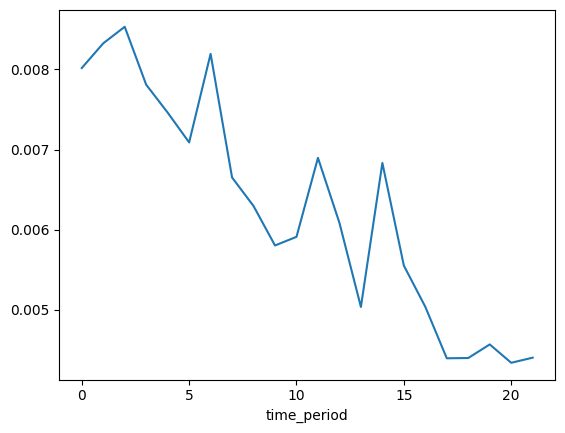

In [61]:
probs.mean(axis=1).plot(legend=False)